In [4]:
import pandas as pd

# Use full path to the file
df = pd.read_csv(r"C:\Users\AUS\Downloads\browsinghistoryview\browsing_history.csv")

print(df.head())  # Display first few rowsS

               https://web.facebook.com/?_rdc=1&_rdr  1517407020  1520809140  \
0            https://drive.google.com/drive/my-drive  1511916240  1520808300   
1                       http://localhost/phpmyadmin/  1519419120  1520778600   
2                           https://www.youtube.com/  1515287460  1520799060   
3  https://console.starter-ca-central-1.openshift...  1511746560  1520777880   
4  https://console.starter-ca-central-1.openshift...  1509489720  1520043900   

   543  95025  
0   28  30912  
1   16  13232  
2   22  12375  
3   22   9830  
4   20   9570  


In [8]:
import os
print(os.getcwd())  # Prints the current working directory


C:\Users\ASUS


In [10]:
import pandas as pd

# Define column names
column_names = ["URL", "Visit Time", "Last Visit Time", "Visit Count", "Typed Count"]

# Load the CSV file with correct headers
df = pd.read_csv(r"C:\Users\ASUS\Downloads\browsinghistoryview\browsing_history.csv", names=column_names, header=0, encoding="utf-8")

# Convert timestamps to readable format
df["Visit Time"] = pd.to_datetime(df["Visit Time"], unit="s", errors="coerce")
df["Last Visit Time"] = pd.to_datetime(df["Last Visit Time"], unit="s", errors="coerce")

# Display the first few rows
print(df.head())

                                                 URL          Visit Time  \
0            https://drive.google.com/drive/my-drive 2017-11-29 00:44:00   
1                       http://localhost/phpmyadmin/ 2018-02-23 20:52:00   
2                           https://www.youtube.com/ 2018-01-07 01:11:00   
3  https://console.starter-ca-central-1.openshift... 2017-11-27 01:36:00   
4  https://console.starter-ca-central-1.openshift... 2017-10-31 22:42:00   

      Last Visit Time  Visit Count  Typed Count  
0 2018-03-11 22:45:00           28        30912  
1 2018-03-11 14:30:00           16        13232  
2 2018-03-11 20:11:00           22        12375  
3 2018-03-11 14:18:00           22         9830  
4 2018-03-03 02:25:00           20         9570  


In [12]:
# List of unwanted sites
blacklist = ["ads.google.com", "tracking.com"]

# Remove these sites from data
df = df[~df["URL"].str.contains("|".join(blacklist))]
print("Cleaned Data:")
print(df.head())


Cleaned Data:
                                                 URL          Visit Time  \
0            https://drive.google.com/drive/my-drive 2017-11-29 00:44:00   
1                       http://localhost/phpmyadmin/ 2018-02-23 20:52:00   
2                           https://www.youtube.com/ 2018-01-07 01:11:00   
3  https://console.starter-ca-central-1.openshift... 2017-11-27 01:36:00   
4  https://console.starter-ca-central-1.openshift... 2017-10-31 22:42:00   

      Last Visit Time  Visit Count  Typed Count  
0 2018-03-11 22:45:00           28        30912  
1 2018-03-11 14:30:00           16        13232  
2 2018-03-11 20:11:00           22        12375  
3 2018-03-11 14:18:00           22         9830  
4 2018-03-03 02:25:00           20         9570  


In [14]:
def categorize_url(url):
    if "facebook" in url or "twitter" in url:
        return "Social Media"
    elif "amazon" in url or "flipkart" in url:
        return "E-commerce"
    elif "bbc" in url or "cnn" in url:
        return "News"
    else:
        return "Other"

df["Category"] = df["URL"].apply(categorize_url)
print(df.head())


                                                 URL          Visit Time  \
0            https://drive.google.com/drive/my-drive 2017-11-29 00:44:00   
1                       http://localhost/phpmyadmin/ 2018-02-23 20:52:00   
2                           https://www.youtube.com/ 2018-01-07 01:11:00   
3  https://console.starter-ca-central-1.openshift... 2017-11-27 01:36:00   
4  https://console.starter-ca-central-1.openshift... 2017-10-31 22:42:00   

      Last Visit Time  Visit Count  Typed Count Category  
0 2018-03-11 22:45:00           28        30912    Other  
1 2018-03-11 14:30:00           16        13232    Other  
2 2018-03-11 20:11:00           22        12375    Other  
3 2018-03-11 14:18:00           22         9830    Other  
4 2018-03-03 02:25:00           20         9570    Other  


In [16]:
top_sites = df["URL"].value_counts().head(10)
print("Top 10 visited sites:\n", top_sites)



Top 10 visited sites:
 URL
https://drive.google.com/drive/my-drive                                                            1
http://localhost/phpmyadmin/                                                                       1
https://web.facebook.com/photo.php?fbid=358244367990826&set=pcb.2230451113852488&type=3&theater    1
https://web.facebook.com/photo.php?fbid=358244387990824&set=pcb.2230451113852488&type=3&theater    1
https://web.facebook.com/photo.php?fbid=358244407990822&set=pcb.2230451113852488&type=3&theater    1
https://web.facebook.com/photo.php?fbid=358244431324153&set=pcb.2230451113852488&type=3&theater    1
https://web.facebook.com/photo.php?fbid=358244454657484&set=pcb.2230451113852488&type=3&theater    1
https://web.facebook.com/photo.php?fbid=358244477990815&set=pcb.2230451113852488&type=3&theater    1
https://web.facebook.com/photo.php?fbid=358244101324186&set=pcb.2230451113852488&type=3&theater    1
https://web.facebook.com/photo.php?fbid=358244124657517&set=pcb.

In [18]:
df["Hour"] = df["Visit Time"].dt.hour
peak_hours = df["Hour"].value_counts().sort_index()
print("Browsing Activity by Hour:\n", peak_hours)


Browsing Activity by Hour:
 Hour
0     194
1     183
2     296
3     139
4      49
5       9
9       6
10      4
11     87
12    175
13     65
14     71
15    107
16     54
17     23
18     86
19    149
20    123
21    163
22    182
23    139
Name: count, dtype: int64


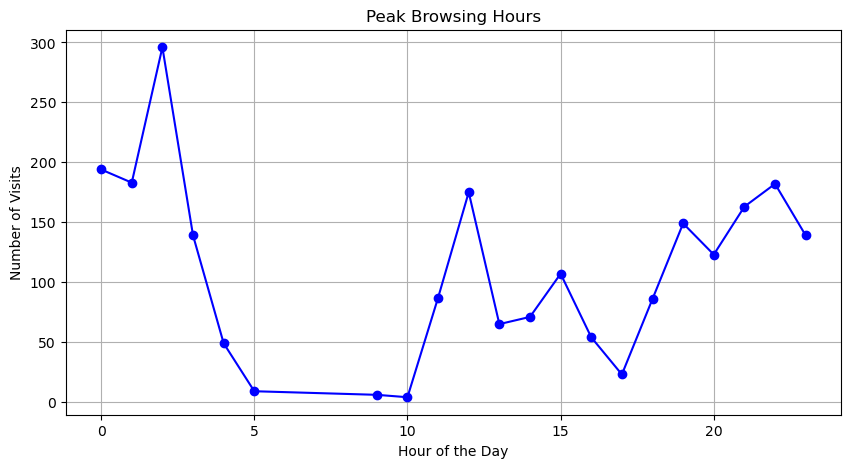

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(peak_hours.index, peak_hours.values, marker="o", linestyle="-", color="b")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Visits")
plt.title("Peak Browsing Hours")
plt.grid(True)
plt.show()


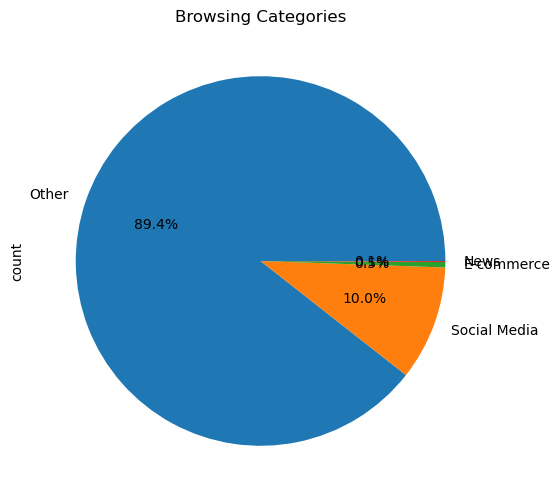

In [23]:
df["Category"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Browsing Categories")
plt.show()


In [25]:
df.to_csv("final_browsing_analysis.csv", index=False)
print("Final report saved successfully!")


Final report saved successfully!
